# Tabu Search — Implementation

This notebook covers the code implementation, experiments, and benchmarks.
For theory and mathematical foundations see **`notebook_theory.ipynb`**.

**Files:**
```
solver.py  — TabuSearch class (nearest-neighbour init + 2-opt neighbourhood)
data.py    — data helpers and dataset loader
```

In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                     SOLVER CONFIGURATION                            ║
# ║  Adjust parameters below. They are used throughout this notebook.  ║
# ║                                                                      ║
# ║  Parameter guide:                                                    ║
# ║    TABU_TENURE — iterations a move stays forbidden (sweet spot:     ║
# ║                  floor(sqrt(n)) to n/5 for a given instance size)   ║
# ║    MAX_ITER    — hard iteration cap                                  ║
# ║    PATIENCE    — early stopping: halt after this many iterations    ║
# ║                  with no improvement (set to MAX_ITER to disable)   ║
# ╚══════════════════════════════════════════════════════════════════════╝

TABU_TENURE = 20     # number of iterations a move stays forbidden
MAX_ITER    = 5000   # hard iteration limit
PATIENCE    = 500    # stop early if no improvement for this many iterations
SEED        = 42

print(f'Tabu Search config: tenure={TABU_TENURE}, max_iter={MAX_ITER}, patience={PATIENCE}, seed={SEED}')

Tabu Search config: tenure=20, max_iter=5000, patience=500, seed=42


In [2]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import permutations
from pathlib import Path

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from data import random_instance, tour_length, optimal_tour, load_cities
from solver import TabuSearch

print('Modules imported successfully.')

# ── Figures output directory ─────────────────────────────────────────────────
# All plots are saved here for inclusion in the LaTeX documentation.
# (docs/src/doc_tabu_search.tex references these via \graphicspath)
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
print(f'Figures will be saved to: {FIGURES_DIR.resolve()}')

Modules imported successfully.
Figures will be saved to: C:\Users\giaco\DEV\CESI\BLOC_RECHERCHE_OPERATIONNELLE\project\rec_op\METAHEURISTICS\tabu_search\figures


## 7. Implementation

| File | Role |
|------|------|
| `solver.py` | `TabuSearch` class — NN init, 2-opt neighbourhood, tabu list, aspiration criterion |
| `data.py` | `random_instance`, `load_cities`, `tour_length`, `optimal_tour` |

## 8. Demonstration

> Small instance (`n=10`) — compare Tabu Search against the brute-force optimal tour.

Optimal tour length : 2.5866
Tabu Search tour    : 2.5866  (gap = 0.0 %)
Iterations run      : 502


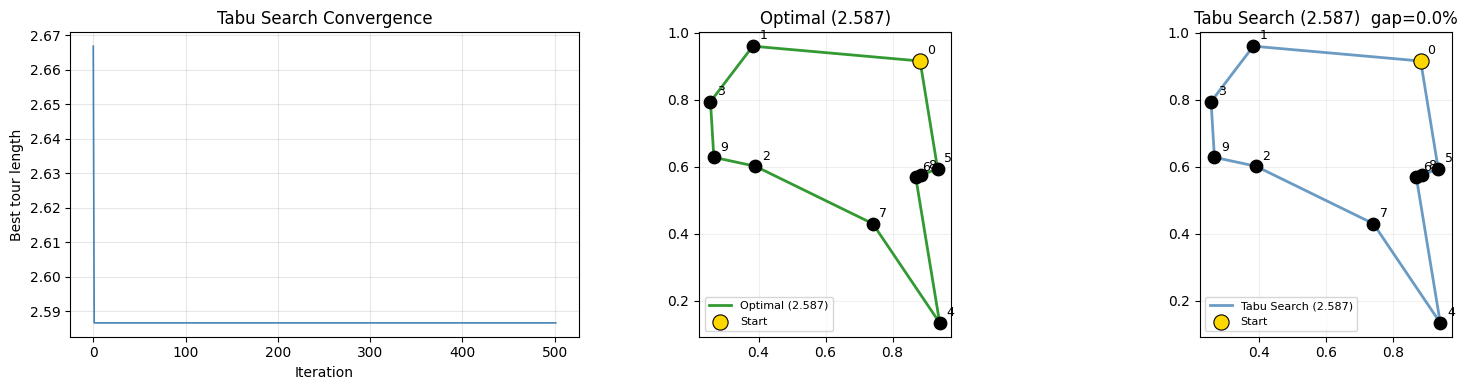

Figure saved → figures\demo_overview.png

TS tour  : 0 → 5 → 8 → 6 → 4 → 7 → 2 → 9 → 3 → 1 → 0
Optimal  : 0 → 1 → 3 → 9 → 2 → 7 → 4 → 6 → 8 → 5 → 0


In [3]:
# ── Demo: n=10, compare TS vs optimal ────────────────────────────────────────
N_DEMO = 10
torch.manual_seed(SEED)
coords = random_instance(N_DEMO)

# Tabu Search
ts = TabuSearch(coords, tabu_tenure=TABU_TENURE,
                max_iter=MAX_ITER, patience=PATIENCE, seed=SEED)
ts_tour, ts_len, history = ts.run()

# Brute-force optimal
opt_tour, opt_len = optimal_tour(coords)

gap = (ts_len - opt_len) / opt_len * 100
print(f'Optimal tour length : {opt_len:.4f}')
print(f'Tabu Search tour    : {ts_len:.4f}  (gap = {gap:.1f} %)')
print(f'Iterations run      : {len(history)}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Convergence curve
axes[0].plot(history, color='steelblue', lw=1.2)
axes[0].set_title('Tabu Search Convergence')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Best tour length')
axes[0].grid(True, alpha=0.3)

xy = coords.numpy()

def draw_tour(ax, xy, tour, color, lw, label):
    tc = tour + [tour[0]]
    for k in range(len(tc) - 1):
        a, b = tc[k], tc[k + 1]
        ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                color=color, lw=lw, alpha=0.8, label=label if k == 0 else None)

# 2) Optimal tour
draw_tour(axes[1], xy, opt_tour, 'green', 2.0, f'Optimal ({opt_len:.3f})')
axes[1].scatter(xy[:, 0], xy[:, 1], s=80, zorder=5, color='black')
axes[1].scatter(xy[0, 0], xy[0, 1], s=120, zorder=6, color='gold',
                edgecolors='black', linewidths=0.8, label='Start')
for i, (xi, yi) in enumerate(xy):
    axes[1].annotate(str(i), (xi + 0.02, yi + 0.02), fontsize=9)
axes[1].set_title(f'Optimal ({opt_len:.3f})')
axes[1].legend(fontsize=8)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.2)

# 3) Tabu Search tour
draw_tour(axes[2], xy, ts_tour, 'steelblue', 2.0, f'Tabu Search ({ts_len:.3f})')
axes[2].scatter(xy[:, 0], xy[:, 1], s=80, zorder=5, color='black')
axes[2].scatter(xy[0, 0], xy[0, 1], s=120, zorder=6, color='gold',
                edgecolors='black', linewidths=0.8, label='Start')
for i, (xi, yi) in enumerate(xy):
    axes[2].annotate(str(i), (xi + 0.02, yi + 0.02), fontsize=9)
axes[2].set_title(f'Tabu Search ({ts_len:.3f})  gap={gap:.1f}%')
axes[2].legend(fontsize=8)
axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'demo_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {FIGURES_DIR / "demo_overview.png"}')
print(f'\nTS tour  : {" → ".join(map(str, ts_tour + [ts_tour[0]]))}')
print(f'Optimal  : {" → ".join(map(str, opt_tour + [opt_tour[0]]))}')

## 9. Benchmark

> Solution quality and runtime vs instance size, compared against the nearest-neighbour (NN) baseline.
> For `n ≤ 10`, also compared against the brute-force optimal.

### Metrics

| Metric | Definition |
|--------|------------|
| **Gap vs NN (%)** | $(L_{TS} - L_{NN}) / L_{NN} \times 100$; negative = TS beats NN |
| **Runtime (s)** | Wall-clock time for one full TS run (NN init + main loop) |
| **Iterations** | Number of iterations executed before stopping criterion fires |
| **Convergence** | Best tour length normalised to the NN initial length, plotted per iteration |

All figures are saved to `figures/` for direct inclusion in `docs/src/doc_tabu_search.tex`.

     n      TS len      NN len   gap vs NN    time (s)   iters
--------------------------------------------------------------
    10      3.7347      4.4134      -15.38%        0.25     503
    50      6.3375      7.5857      -16.46%        7.59     603
   100      8.0379      9.5817      -16.11%       27.16     528
   200     11.3322     13.9632      -18.84%      139.44     631


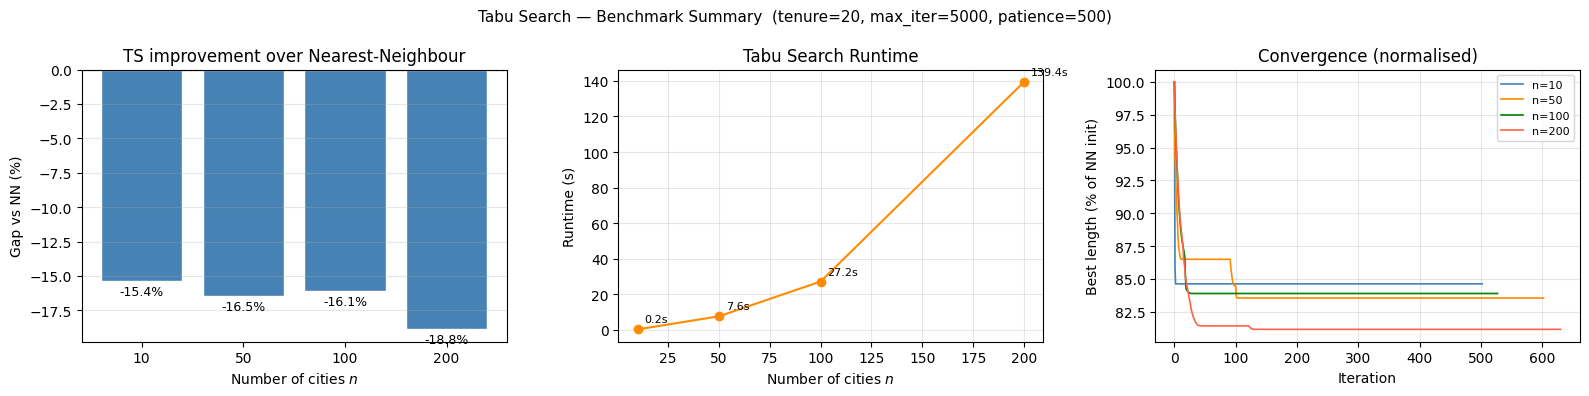

Figure saved → figures\benchmark_summary.png


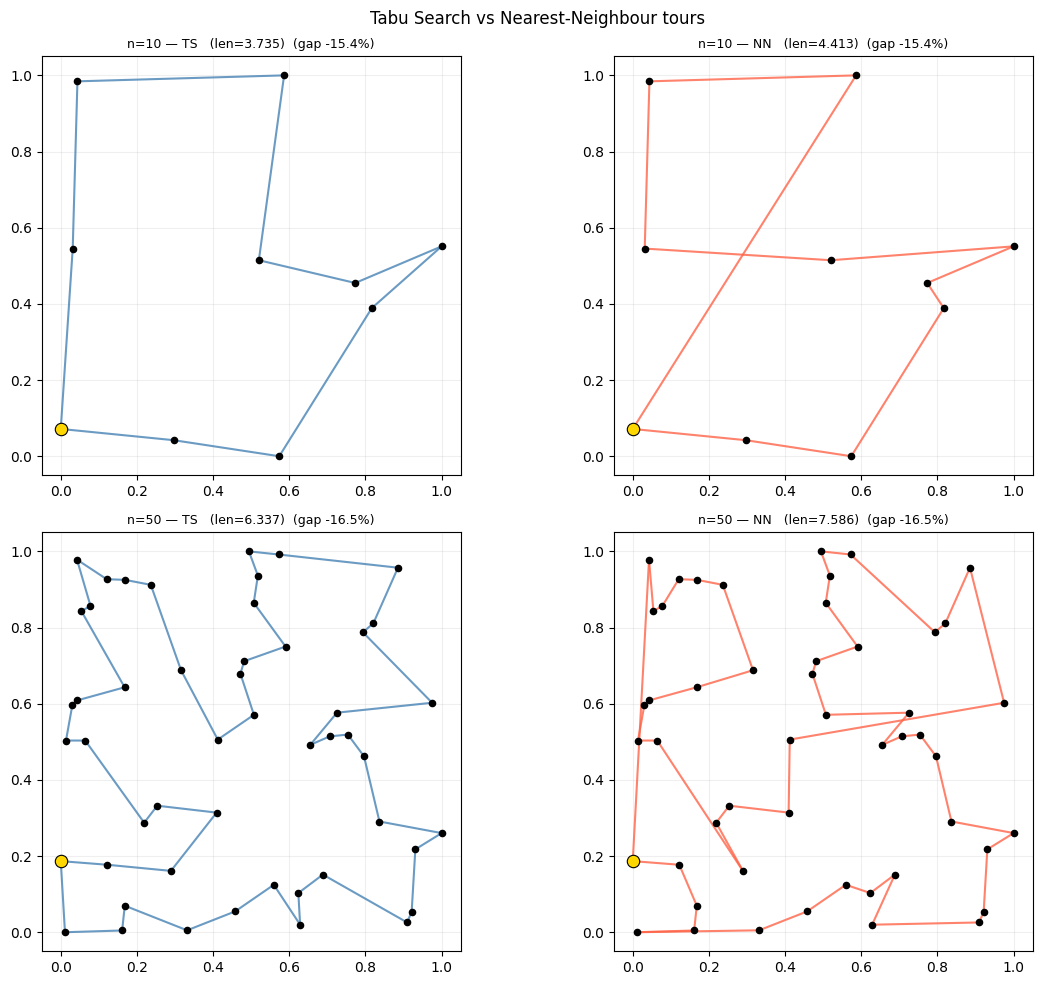

Figure saved → figures\benchmark_tours.png


In [4]:
# ── Benchmark across sizes ────────────────────────────────────────────────────
BENCH_SIZES = [10, 50, 100, 200]
results = []

print(f"{'n':>6}  {'TS len':>10}  {'NN len':>10}  {'gap vs NN':>10}  {'time (s)':>10}  {'iters':>6}")
print('-' * 62)

for n in BENCH_SIZES:
    coords = load_cities(n, source='tsp')

    # Nearest-neighbour baseline (reuse internal helper via a zero-iteration solver)
    ts_temp = TabuSearch(coords, tabu_tenure=1, max_iter=0, patience=0)
    nn_tour = ts_temp._nearest_neighbour()
    nn_len  = tour_length(coords, nn_tour)

    # Tabu Search
    t0 = time.perf_counter()
    ts = TabuSearch(coords, tabu_tenure=TABU_TENURE,
                    max_iter=MAX_ITER, patience=PATIENCE, seed=SEED)
    ts_tour, ts_len, history = ts.run()
    elapsed = time.perf_counter() - t0

    gap = (ts_len - nn_len) / nn_len * 100
    results.append({'n': n, 'ts': ts_len, 'nn': nn_len, 'gap': gap,
                    'time': elapsed, 'iters': len(history),
                    'coords': coords, 'ts_tour': ts_tour,
                    'nn_tour': nn_tour, 'history': history})
    print(f"{n:>6}  {ts_len:>10.4f}  {nn_len:>10.4f}  {gap:>+10.2f}%  {elapsed:>10.2f}  {len(history):>6}")

# ── Figure 1: benchmark_summary ───────────────────────────────────────────────
# Three panels: gap vs NN  |  runtime  |  normalised convergence curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Tabu Search — Benchmark Summary  '
             f'(tenure={TABU_TENURE}, max_iter={MAX_ITER}, patience={PATIENCE})',
             fontsize=11)

ns   = [r['n']    for r in results]
gaps = [r['gap']  for r in results]
ts_t = [r['time'] for r in results]

# 1) Gap vs NN per size
colors = ['steelblue' if g <= 0 else 'tomato' for g in gaps]
bars = axes[0].bar([str(n) for n in ns], gaps, color=colors, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].bar_label(bars, fmt='%.1f%%', fontsize=9, padding=3)
axes[0].set_xlabel('Number of cities $n$')
axes[0].set_ylabel('Gap vs NN (%)')
axes[0].set_title('TS improvement over Nearest-Neighbour')
axes[0].grid(True, axis='y', alpha=0.3)

# 2) Runtime vs size
axes[1].plot(ns, ts_t, 'o-', color='darkorange', lw=1.5)
axes[1].set_xlabel('Number of cities $n$')
axes[1].set_ylabel('Runtime (s)')
axes[1].set_title('Tabu Search Runtime')
axes[1].grid(True, alpha=0.3)
for n, t in zip(ns, ts_t):
    axes[1].annotate(f'{t:.1f}s', (n, t), textcoords='offset points',
                     xytext=(5, 5), fontsize=8)

# 3) Convergence curves (normalised to NN initial length)
palette = ['steelblue', 'darkorange', 'green', 'tomato']
for r, c in zip(results, palette):
    norm = [h / r['nn'] * 100 for h in r['history']]
    axes[2].plot(norm, color=c, lw=1.2, label=f"n={r['n']}")
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Best length (% of NN init)')
axes[2].set_title('Convergence (normalised)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'benchmark_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {FIGURES_DIR / "benchmark_summary.png"}')

# ── Figure 2: benchmark_tours ─────────────────────────────────────────────────
# Tour visualisation for n=10 and n=50 (TS blue, NN red)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Tabu Search vs Nearest-Neighbour tours', fontsize=12)

for row, r in enumerate(results[:2]):
    xy = r['coords'].numpy()
    for col, (tour, color, title) in enumerate([
        (r['ts_tour'], 'steelblue', f"TS   (len={r['ts']:.3f})"),
        (r['nn_tour'], 'tomato',    f"NN   (len={r['nn']:.3f})"),
    ]):
        ax = axes[row][col]
        tc = tour + [tour[0]]
        for k in range(len(tc) - 1):
            a, b = tc[k], tc[k + 1]
            ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                    color=color, lw=1.5, alpha=0.8)
        ax.scatter(xy[:, 0], xy[:, 1], s=20, zorder=5, color='black')
        ax.scatter(xy[0, 0], xy[0, 1], s=80, zorder=6, color='gold',
                   edgecolors='black', linewidths=0.8)
        ax.set_title(f"n={r['n']} — {title}  (gap {r['gap']:+.1f}%)", fontsize=9)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'benchmark_tours.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {FIGURES_DIR / "benchmark_tours.png"}')

## 9b. Solution Quality on Real Dataset

> Tests Tabu Search on instances loaded from the CSV dataset.
> Each instance is compared against a **nearest-neighbour (NN) baseline**.

### Metrics

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Tour length** | $\sum_k d(c_k, c_{k+1})$ | Total Euclidean distance of the tour |
| **Gap vs NN** | $(L_{TS} - L_{NN}) / L_{NN} \times 100\%$ | Relative difference; negative = TS beats NN |
| **Win rate** | $\#\{L_{TS} \le L_{NN}\} / N$ | Fraction of instances where TS is better or equal |

In [5]:
# ── Solution quality on real dataset ─────────────────────────────────────────
EVAL_SIZES  = [10, 50, 100, 200]
N_REPS_QUAL = 10   # independent runs per size (different seeds)

qual_records = []

print(f"{'n':>6}  {'TS len':>10}  {'NN len':>10}  {'gap %':>8}  {'time (s)':>10}  {'win?':>5}")
print('-' * 58)

for n in EVAL_SIZES:
    ts_lens, nn_lens, times = [], [], []

    for rep in range(N_REPS_QUAL):
        coords = load_cities(n, source='tsp')

        # NN baseline
        ts_temp  = TabuSearch(coords, tabu_tenure=1, max_iter=0, patience=0)
        nn_tour  = ts_temp._nearest_neighbour()
        nn_len   = tour_length(coords, nn_tour)

        # Tabu Search
        t0 = time.perf_counter()
        ts = TabuSearch(coords, tabu_tenure=TABU_TENURE,
                        max_iter=MAX_ITER, patience=PATIENCE, seed=SEED + rep)
        ts_tour, ts_len, _ = ts.run()
        times.append(time.perf_counter() - t0)

        ts_lens.append(ts_len)
        nn_lens.append(nn_len)

    mean_ts  = float(np.mean(ts_lens))
    mean_nn  = float(np.mean(nn_lens))
    mean_gap = (mean_ts - mean_nn) / mean_nn * 100
    mean_t   = float(np.mean(times))
    win_rate = float(np.mean([ts <= nn for ts, nn in zip(ts_lens, nn_lens)])) * 100

    qual_records.append({
        'n': n, 'ts': mean_ts, 'nn': mean_nn,
        'gap': mean_gap, 'time': mean_t, 'win': win_rate,
        'ts_lens': ts_lens, 'nn_lens': nn_lens,
    })
    win_str = 'TS' if mean_gap <= 0 else 'NN'
    print(f"{n:>6}  {mean_ts:>10.4f}  {mean_nn:>10.4f}  {mean_gap:>+8.2f}%  "
          f"{mean_t:>10.2f}  {win_str:>5}  (win rate {win_rate:.0f}%)")

# ── Gap summary bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Tabu Search — Solution Quality on Real Dataset', fontsize=11)

ns   = [r['n']   for r in qual_records]
gaps = [r['gap'] for r in qual_records]
wins = [r['win'] for r in qual_records]

colors = ['steelblue' if g <= 0 else 'tomato' for g in gaps]
bars = axes[0].bar([str(n) for n in ns], gaps, color=colors, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].bar_label(bars, fmt='%.1f%%', fontsize=9, padding=3)
axes[0].set_xlabel('Number of cities $n$')
axes[0].set_ylabel('Mean gap vs NN (%)')
axes[0].set_title('Mean gap vs NN  (blue = TS wins)')
axes[0].grid(True, axis='y', alpha=0.3)

bars2 = axes[1].bar([str(n) for n in ns], wins, color='steelblue', edgecolor='white')
axes[1].axhline(50, color='black', lw=0.8, ls='--')
axes[1].bar_label(bars2, fmt='%.0f%%', fontsize=9, padding=3)
axes[1].set_xlabel('Number of cities $n$')
axes[1].set_ylabel('Win rate (%)')
axes[1].set_title(f'TS win rate over NN  ({N_REPS_QUAL} runs per size)')
axes[1].set_ylim(0, 120)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'solution_quality_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {FIGURES_DIR / "solution_quality_gap.png"}')

     n      TS len      NN len     gap %    time (s)   win?
----------------------------------------------------------
    10      3.7347      4.4134    -15.38%        0.27     TS  (win rate 100%)
    50      6.3375      7.5857    -16.46%        7.59     TS  (win rate 100%)
   100      8.0379      9.5817    -16.11%       26.98     TS  (win rate 100%)


KeyboardInterrupt: 